In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plots

In [2]:
df = pd.read_json('../../../results/smc/local/r_logistic_int_config.json')

Text(0.5, 1.0, 'Total CPU: 41600.0')

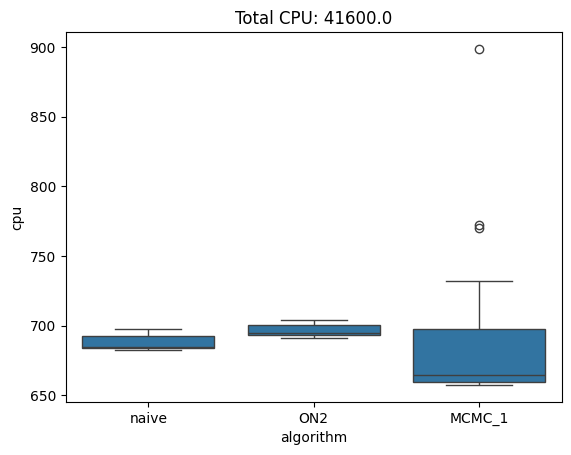

In [3]:
fig, ax = plt.subplots(1, 1)
sns.boxplot(ax=ax, data=df, x='algorithm', y='cpu')
ax.set_title(f'Total CPU: {round(df["cpu"].sum(), -2)}')

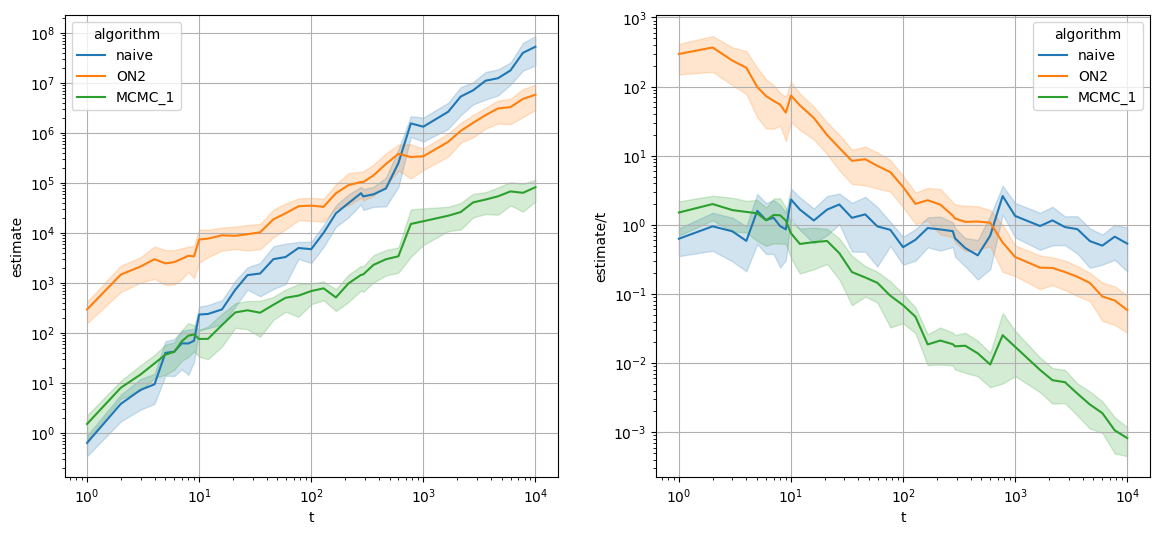

In [4]:
import numpy as np

data = plots.load('logistic_int_config.json')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

long_df = data['smc_long']

long_df['estimate/t'] = long_df['estimate'] / long_df['t']

sns.lineplot(ax=axes[0], data=long_df, x='t', y='estimate', hue='algorithm', estimator=lambda x: np.var(x, ddof=1), errorbar=("ci", 95), n_boot=1000)
sns.lineplot(ax=axes[1], data=long_df, x='t', y='estimate/t', hue='algorithm', estimator=lambda x: np.var(x, ddof=1), errorbar=("ci", 95), n_boot=1000)

for ax in axes.ravel():
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid()

In [5]:
df.groupby('cpu').mean

<bound method GroupBy.mean of <pandas.core.groupby.generic.DataFrameGroupBy object at 0x1084130d0>>

In [6]:
data = plots.load('aux_bridge_config.json')

<Axes: xlabel='algorithm', ylabel='1000'>

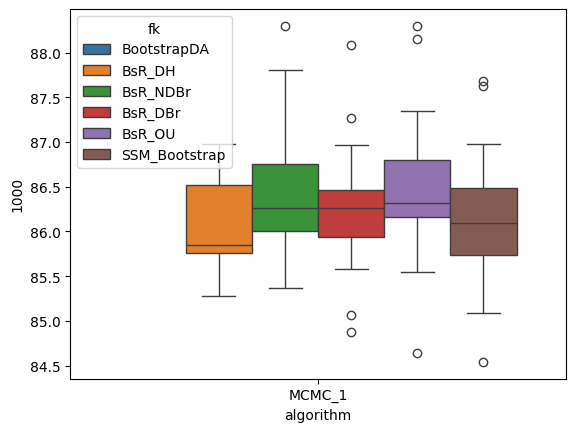

In [7]:
df = data['smc_wide'].copy()
df['algorithm'] = df['algorithm'][df['algorithm'] == 'MCMC_1']

fig, ax = plt.subplots()

sns.boxplot(ax=ax, data=df, x='algorithm', hue='fk', y='1000')

In [4]:
def cpu_times_boxplot(ax, data: dict):
    
    smc_df = data['smc_wide']
    
    sns.boxplot(
        ax=ax,
        data=smc_df,
        x='algorithm',
        y='cpu',
        color='forestgreen',     # internal box colour
        width=0.55,
        linewidth=2.0,        # thicker box/whisker lines
        fliersize=6,
        flierprops={
            'marker': 'o',
            'markerfacecolor': 'white',
            'markeredgecolor': '0.25',
            'markeredgewidth': 1.4
        }
    )

    ax.set_xticklabels([
        "GT: $\\mathcal{O}(N)$\n$N=44100$",
        "FFBS: $\\mathcal{O}(N^2)$\n$N=100$",
        "FFBS-MCMC: $\\mathcal{O}(N)$\n$N=11000$"
    ])

    ax.set_xlabel("")
    ax.set_ylabel("CPU time", fontsize=12)

    ax.tick_params(axis='both', labelsize=11)
    ax.tick_params(axis='x', pad=8)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.25)
    ax.xaxis.grid(False)

    sns.despine(ax=ax)
    return ax